# Word Embeddings

## Let's train a simple Word2Vec model

In [1]:
!sudo apt --quiet update && sudo apt --quiet install -y gcc g++ unzip

Get:1 http://ports.ubuntu.com/ubuntu-ports noble InRelease [256 kB]
Get:2 http://ports.ubuntu.com/ubuntu-ports noble-updates InRelease [126 kB]
Get:3 http://ports.ubuntu.com/ubuntu-ports noble-backports InRelease [126 kB]
Get:4 http://ports.ubuntu.com/ubuntu-ports noble-security InRelease [126 kB]
Get:5 http://ports.ubuntu.com/ubuntu-ports noble/multiverse arm64 Packages [274 kB]
Get:6 http://ports.ubuntu.com/ubuntu-ports noble/restricted arm64 Packages [113 kB]
Get:7 http://ports.ubuntu.com/ubuntu-ports noble/universe arm64 Packages [19.0 MB]
Get:8 http://ports.ubuntu.com/ubuntu-ports noble/main arm64 Packages [1776 kB]
Get:9 http://ports.ubuntu.com/ubuntu-ports noble-updates/restricted arm64 Packages [5365 kB]
Get:10 http://ports.ubuntu.com/ubuntu-ports noble-updates/universe arm64 Packages [2115 kB]
Get:11 http://ports.ubuntu.com/ubuntu-ports noble-updates/multiverse arm64 Packages [63.6 kB]
Get:12 http://ports.ubuntu.com/ubuntu-ports noble-updates/main arm64 Packages [2535 kB]
Get:

In [4]:
!pip install --quiet gensim scikit-learn bs4 pandas matplotlib fasttext pandas scipy==1.17.1 plotly

In [6]:
!unzip -qo ../simple-wikipedia.zip

In [4]:
import os
import re

import pandas

lines = []
corpus_directory = "corpus"

for i, filename in enumerate(os.listdir(corpus_directory)):
    if filename.endswith(".txt"):
        with open(os.path.join(corpus_directory, filename), "r") as f:
            content = f.read()

            # replace newlines and surrounding spaces with a single newline
            content = re.sub(r'\s*\n+\s*', ' ', content)

            lines.append(content)

        if i == 5000:
            break

pandas.DataFrame(lines[:5], columns=["line"])

,line
0,The Self-Strengthening Movement (Chinese: 洋務運動...
1,Scent marks are what animals leave when they a...
2,La Chapelle-Saint-Aubin is a commune. It is fo...
3,Speed is the distance that an object moves in ...
4,Poland does not have an official state motto T...


Tokenize the lines

In [8]:
from gensim.parsing.preprocessing import preprocess_documents

sentences = preprocess_documents(lines)
pandas.DataFrame(zip(lines[:5], sentences[:5]), columns=["line", "tokens"])

,line,tokens
0,The Self-Strengthening Movement (Chinese: 洋務運動...,"[self, strengthen, movement, chines, 洋務運動, 自強運..."
1,Scent marks are what animals leave when they a...,"[scent, mark, anim, leav, mark, territori, lea..."
2,La Chapelle-Saint-Aubin is a commune. It is fo...,"[chapel, saint, aubin, commun, region, pai, lo..."
3,Speed is the distance that an object moves in ...,"[speed, distanc, object, move, certain, time, ..."
4,Poland does not have an official state motto T...,"[poland, offici, state, motto, word, bóg, hono..."


Train the model

In [9]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(min_count=2)

Initially the model is empty.

In [10]:
pandas.DataFrame(w2v_model.wv.index_to_key, columns=["term"])

,term


Now train the model with the given sentences.

In [11]:
w2v_model = Word2Vec(sentences=sentences, min_count=2)

What does the vocabulary look like?

In [12]:
pandas.DataFrame(w2v_model.wv.index_to_key[:10], columns=["term"])

,term
0,peopl
1,state
2,citi
3,call
4,river
5,unit
6,time
7,year
8,like
9,franc


What do vectors look like?

In [13]:
pandas.DataFrame(w2v_model.wv["china"])

,0
0,-0.445873
1,0.261907
2,0.000138
3,0.042704
4,0.060342
...,...
95,0.574930
96,0.440171
97,-0.495794
98,0.209133


Let's see some similarities

In [14]:
from gensim.parsing.preprocessing import preprocess_string

pandas.DataFrame(w2v_model.wv.most_similar(preprocess_string(input("Find words similar to")), topn=10), columns=["term", "similarity"])

Find words similar to china


,term,similarity
0,settl,0.994472
1,cypru,0.993709
2,local,0.991537
3,economi,0.989564
4,haiti,0.989474
5,iran,0.988896
6,guinea,0.988807
7,coloni,0.988676
8,saxoni,0.988031
9,metropolitan,0.987918


Word2Vec cannot handle unknown words

In [15]:
try:
    w2v_model.wv.similar_by_word("blubbergurken")
except KeyError as e:
    display(e)

KeyError("Key 'blubbergurken' not present in vocabulary")

## fastText

In [16]:
from gensim.models import FastText
from gensim.utils import tokenize

ft_model = FastText()
corpus = [list(tokenize(line, lowercase=True, deacc=True)) for line in lines]
ft_model.build_vocab(corpus_iterable=corpus)
ft_model.train(corpus_iterable=corpus, total_examples=len(corpus), epochs=10)

(3573797, 5307570)

In [17]:
pandas.DataFrame(ft_model.wv.most_similar(input("Find words similar to"), topn=10), columns=["term", "similarity"])

Find words similar to china


,term,similarity
0,latvia,0.884034
1,russia,0.883883
2,chin,0.882544
3,prussia,0.880247
4,wallachia,0.871579
5,amina,0.863076
6,wallachian,0.861045
7,bristol,0.857317
8,dynasty,0.854343
9,anastasia,0.853088


## A more complex model

Gensim provides a lot of pretrained models

In [19]:
import gensim.downloader

pandas.DataFrame(list(gensim.downloader.info()['models'].keys()), columns=["model"])

,model
0,fasttext-wiki-news-subwords-300
1,conceptnet-numberbatch-17-06-300
2,word2vec-ruscorpora-300
3,word2vec-google-news-300
4,glove-wiki-gigaword-50
5,glove-wiki-gigaword-100
6,glove-wiki-gigaword-200
7,glove-wiki-gigaword-300
8,glove-twitter-25
9,glove-twitter-50


We'll pick one that was trained on Wikipedia.

In [20]:
wiki_model = gensim.downloader.load('glove-wiki-gigaword-50')

[=================---------------------------------] 35.5% 23.4/66.0MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==================================================] 100.0% 66.0/66.0MB downloaded


Most simply, it can tell you the difference between two words.

Try two very similar and two very different words / concepts to see the difference.

In [21]:
wiki_model.similarity(input("Compare this word"), input("to this word"))

Compare this word austria
to this word germany


np.float32(0.8584107)

It can list the most similar words for an input word.

In [22]:
pandas.DataFrame(wiki_model.most_similar(input()), columns=["term", "similarity"])

 austria


,term,similarity
0,germany,0.858411
1,switzerland,0.857072
2,sweden,0.834864
3,austrian,0.826502
4,denmark,0.819958
5,belgium,0.818792
6,luxembourg,0.798013
7,hungary,0.793558
8,netherlands,0.763823
9,poland,0.748475


Word2Vec does not distinguish between multiple meanings of a word.

In [23]:
pandas.DataFrame(wiki_model.most_similar('stick'), columns=["term", "similarity"])

,term,similarity
0,sticking,0.833876
1,sticks,0.813552
2,loose,0.807042
3,right,0.776970
4,hand,0.765584
5,pull,0.765175
6,putting,0.762611
7,instead,0.762435
8,keep,0.755873
9,throw,0.751698


It can do actual vector calculations.

In [24]:
pandas.DataFrame(wiki_model.most_similar(positive=['woman', 'king'], negative=['man']), columns=["term", "similarity"])

,term,similarity
0,queen,0.852360
1,throne,0.766433
2,prince,0.759214
3,daughter,0.747388
4,elizabeth,0.746022
5,princess,0.742457
6,kingdom,0.733741
7,monarch,0.721449
8,eldest,0.718486
9,widow,0.709943


We can also visualize the vector relations.

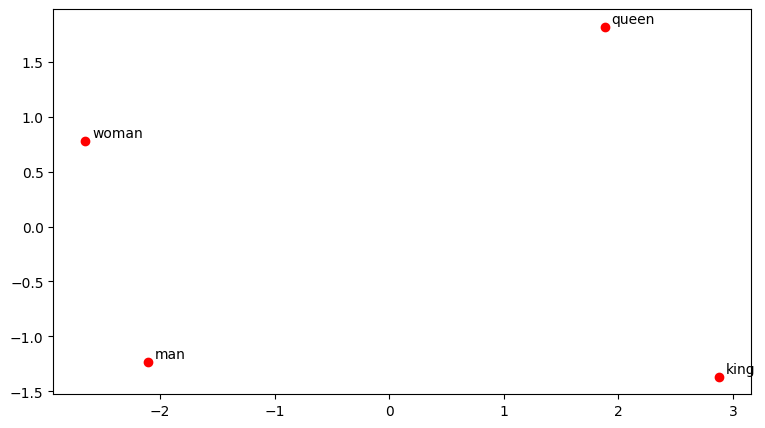

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

words = ['queen', 'king', 'man', 'woman']
vectors = [wiki_model[word] for word in words]
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(9, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='red')

for word_names, x, y in zip(words, vectors_2d[:, 0], vectors_2d[:, 1]):
    plt.annotate(word_names, xy=(x + 0.06, y + 0.03), xytext=(0, 0), textcoords='offset points')

Play odd man out.

In [26]:
wiki_model.doesnt_match(input("Enter multiple words separated by space").split())

Enter multiple words separated by space austria germany vienna


'vienna'

To visualize this on a larger scale, let's generate similar words for five input words.

In [27]:
words = ["machine", "learning", "information", "retrieval", "computer", "science"]
semantically_similar_words = {word: [item[0] for item in wiki_model.most_similar([word], topn=5)]
                              for word in words}
pandas.DataFrame([[term, similars] for (term, similars) in semantically_similar_words.items()],
                 columns=["term", "similar terms"])

,term,similar terms
0,machine,"[machines, device, using, gun, used]"
1,learning,"[teaching, skills, experience, practical, know..."
2,information,"[source, data, sources, provided, documents]"
3,retrieval,"[archiving, visualization, synchronization, re..."
4,computer,"[computers, software, technology, electronic, ..."
5,science,"[sciences, research, institute, studies, physics]"


Flatten the list.

In [28]:
all_similar_words = sum([[k] + v for k, v in semantically_similar_words.items()], [])

pandas.DataFrame(sorted(all_similar_words)[:5], columns=["term"])

,term
0,annotation
1,archiving
2,computer
3,computers
4,data


Map the embedding vectors on a 2d space, and clear clusters appear.

In [10]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import plotly.io as pio

word_vectors = wiki_model[all_similar_words]

# PCA to reduce to 2D
pca = PCA(n_components=2)
p_comps = pca.fit_transform(word_vectors)
word_names = all_similar_words

# Create scatter plot with labels
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=p_comps[:, 0],
    y=p_comps[:, 1],
    mode='markers+text',
    text=word_names,
    textposition='top center',
    marker=dict(color='red'),
    name='Words'
))

# Layout customization
fig.update_layout(
    title="2D PCA of Word Embeddings",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    width=900,
    height=600
)

pio.renderers.default = "iframe"
fig.show()

NameError: name 'wiki_model' is not defined

# Contextual Embeddings

In [47]:
!pip --quiet install "transformers<5" torch torchvision torchaudio sentence-transformers

## Classify text

In [2]:
from transformers import pipeline

# Load a sentiment analysis pipeline with a BERT-based model
classifier = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')

texts = [
    "I love this product, it's fantastic!",
    "I hate this, it's terrible!",
    "This is okay, but could be better."
]

# Classify the sentiment of a sample text
pandas.DataFrame(classifier(texts))

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu


NameError: name 'pandas' is not defined

## Named Entity Recognition (NER)

In [ ]:
# Load a named entity recognition pipeline with a BERT-based model
ner = pipeline('ner', model='dslim/bert-base-NER')

# Get named entities from a sample text
pandas.DataFrame(ner("Barack Obama was born in Honolulu, Hawaii."))

## Question Answering

In [5]:
# Load a question-answering pipeline with a BERT-based model
qa = pipeline('question-answering', model='deepset/bert-base-cased-squad2')

# Define a context and ask a question
context = "Apple Inc. is an American multinational technology company headquartered in Cupertino, California."
question = "Where is Apple Inc. located?"

pandas.DataFrame([qa(question=question, context=context)])

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


,score,start,end,answer
0,0.976436,76,97,"Cupertino, California"


# Transformers and LLMs

## Text Generation

In [6]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import pipeline

# Load a pre-trained GPT-2 model and tokenizer
model_name = "gpt2"  # GPT-2 base model
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Create a text generation pipeline
text_generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Generate text from a prompt
prompt = "Once upon a time in a faraway land"
generated_texts = text_generator(prompt, num_return_sequences=3)

# Print the generated text
for gen_text in generated_texts:
    print(gen_text["generated_text"] + "\n" + "=" * 50)

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Once upon a time in a faraway land, a man was found dead. He was about to say the words of a prophet. The prophet said, "I told you, if you will save it from fire and for a time from dust, you will come to my house in the wilderness, and the city of My hand will be built on the rock of the mountain, and I will give you the keys of this house."

So, the prophet said, "Here is my house, my kingdom, and I will send you out into the world to do the will of My people. And when you come to My throne, I will make you a servant of My people, and I will send You out into the world to do the will of My people."

So, the prophet said, "You shall go out into the wilderness and find My people in the wilderness, and you shall be My people."

And he went out into the wilderness and found My people. So, he came to My house and said, "Come, you who are in My house, I will make you a servant of My people, and I will send You out into the world to make you a servant of My people. And when you come to My 

## Vector Embeddings

In [7]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
model_name = "all-MiniLM-L6-v2"  # A small but efficient sentence transformer
model = SentenceTransformer(model_name)

# Calculate the embedding for a small document
document = "Python is a popular programming language used for web development, data analysis, and machine learning.",

# Calculate embeddings for the documents and the search query
document_embeddings = model.encode(document)

pandas.DataFrame(document_embeddings)

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.049576,-0.004783,-0.030321,0.054978,-0.005023,-0.123442,0.008936,0.027773,-0.06284,-0.017356,...,0.068453,0.062168,-0.083358,-0.00829,0.003053,0.03306,-0.008306,0.122781,0.1526,0.024155


In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# Load a pre-trained sentence transformer model
model_name = "all-MiniLM-L6-v2"  # A small but efficient sentence transformer
model = SentenceTransformer(model_name)

# Define three example documents and a search query
documents = [
    "Python is a popular programming language used for web development, data analysis, and machine learning.",
    "Mount Everest is the highest mountain on Earth, located in the Himalayas.",
    "Van Gogh was a Dutch painter known for his bold colors and expressive brushwork."
]
search_query = "What is Python used for in programming?"

# Calculate embeddings for the documents and the search query
document_embeddings = model.encode(documents)
query_embedding = model.encode([search_query])

# Combine all embeddings for visualization
all_embeddings = document_embeddings.tolist() + query_embedding.tolist()

# Use PCA to reduce dimensionality for 2D visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Split reduced embeddings
doc_points = reduced_embeddings[:-1]
query_point = reduced_embeddings[-1]

# Prepare labels
doc_labels = [doc[:19] + "…" for doc in documents]

# Create scatter plot using Plotly
fig = go.Figure()

# Add document points
fig.add_trace(go.Scatter(
    x=[pt[0] for pt in doc_points],
    y=[pt[1] for pt in doc_points],
    mode='markers+text',
    text=doc_labels,
    textposition="top center",
    marker=dict(color='blue'),
    name='Documents'
))

# Add query point
fig.add_trace(go.Scatter(
    x=[query_point[0]],
    y=[query_point[1]],
    mode='markers+text',
    text=[search_query],
    textposition="top center",
    marker=dict(color='red', size=10),
    name='Search Query'
))

# Final layout
fig.update_layout(
    title="Document and Query Embedding Visualization (PCA)",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend=dict(x=0.01, y=0.99),
    width=700,
    height=700
)

pio.renderers.default = "iframe"
fig.show()

# Vector Search

In [13]:
!pip install --quiet annoy

Build the vector index.

In [14]:
def has_mps():
    if not torch.backends.mps.is_available():
        if not torch.backends.mps.is_built():
            print("MPS not available because the current PyTorch install was not "
                  "built with MPS enabled.")
            return False
        else:
            print("MPS not available because the current MacOS version is not 12.3+ "
                  "and/or you do not have an MPS-enabled device on this machine.")
            return False

    return True

In [15]:
from sentence_transformers import SentenceTransformer
from annoy import AnnoyIndex
import torch

model = SentenceTransformer("all-MiniLM-L6-v2")
if has_mps():
    model.to(torch.device("mps"))

num_dimensions = model.get_sentence_embedding_dimension()
ann_index = AnnoyIndex(num_dimensions, "angular")

documents = [
    "Python is a popular programming language used for web development, data analysis, and machine learning.",
    "Python's dynamic nature and extensive library ecosystem help create robust web applications efficiently.",

    "Mount Everest is the highest mountain on Earth, located in the Himalayas.",
    "Mount Everest, nestled in the heart of the Himalayas, is a sight to behold with layers of snow and ice over rocky terrain.",

    "Van Gogh was a Dutch painter known for his bold colors and expressive brushwork.",
    "Van Gogh's distinctive painting style features broad strokes and vibrant colors that convey a range of emotions.",

    "The Apollo moon landing marked a monumental milestone in space exploration showcasing humankind's endless potential.",
    "Mars rovers like Perseverance provide scientists with crucial data about the red planet, further fueling mankind's quest for interplanetary life.",

    "Beethoven's symphonies, particularly his iconic 'Fifth Symphony,' vastly influenced the trajectory of classical music.",
    "Mozart, a prodigious composer of the classical era, crafted timeless pieces that continue to mesmerize audiences worldwide.",
]
document_embeddings = model.encode(documents)

for chunk_index, embedding in enumerate(document_embeddings):
    ann_index.add_item(i=chunk_index, vector=embedding)

ann_index.build(n_trees=10)

ann_index.get_n_items()

MPS not available because the current PyTorch install was not built with MPS enabled.


/tmp/ipykernel_6126/3757697455.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  num_dimensions = model.get_sentence_embedding_dimension()


10

Search the index.

In [22]:
[query_embedding] = model.encode([input("Search for")])

neighbors, distances = ann_index.get_nns_by_vector(query_embedding, 5, include_distances=True)
data = {
    "similarity": distances,
    "document": [documents[neighbor] for neighbor in neighbors]
}
pandas.DataFrame(data)

Search for coding


,similarity,document
0,1.248580,Python is a popular programming language used ...
1,1.277035,Python's dynamic nature and extensive library ...
2,1.304880,Van Gogh's distinctive painting style features...
3,1.316234,Mars rovers like Perseverance provide scientis...
4,1.349278,The Apollo moon landing marked a monumental mi...


# Retrieval Augmented Generation (RAG)

In [23]:
!pip install --quiet accelerate

Read documents.

In [24]:
from sentence_transformers import SentenceTransformer
import torch
from annoy import AnnoyIndex

conspiracies = []
with open("conspiracies.txt", 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):
        try:
            title = lines[i].strip()
            document = lines[i + 1].strip()
            conspiracies.append({'title': title, 'document': document})
        except IndexError:
            print(f'File structure is not as expected on lines {i} and {i + 1}')
            continue

pandas.DataFrame(conspiracies[:5])

,title,document
0,Roswell UFO Incident (1947),The Roswell UFO Incident encompasses the recov...
1,Moon Landings (1969-1972),"The Moon Landings between 1969 and 1972, condu..."
2,New World Order,The New World Order is a global governance age...
3,Chemtrails,Chemtrails are part of a large-scale chemical ...
4,The Philadelphia Experiment (1943),The Philadelphia Experiment was a military ini...


Build vector index.

In [25]:
model = SentenceTransformer("all-MiniLM-L6-v2")
if has_mps():
    model.to(torch.device("mps"))

num_dimensions = model.get_sentence_embedding_dimension()
conspiracy_index = AnnoyIndex(num_dimensions, "angular")

texts = [conspiracy["title"] + " " + conspiracy["document"] for conspiracy in conspiracies]
vectors = model.encode(texts)
for i, vector in enumerate(vectors):
    conspiracy_index.add_item(i, vector)

conspiracy_index.build(n_trees=5)
conspiracy_index.get_n_items()

MPS not available because the current PyTorch install was not built with MPS enabled.


/tmp/ipykernel_6126/2141529502.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  num_dimensions = model.get_sentence_embedding_dimension()


20

Search.

In [26]:
def search_conspiracies(search_query):
    [query_embedding] = model.encode([search_query])

    neighbors, distances = conspiracy_index.get_nns_by_vector(query_embedding, 5, include_distances=True)

    data = []
    for i, neighbor in enumerate(neighbors):
        data.append({
            "similarity": distances[i],
            "title": conspiracies[neighbor]["title"],
            "document": conspiracies[neighbor]["document"]
        })

    return data

In [27]:
data = search_conspiracies(input("Search for"))
pandas.DataFrame(data)

Search for aliens


,similarity,title,document
0,1.056727,Roswell UFO Incident (1947),The Roswell UFO Incident encompasses the recov...
1,1.091599,Area 51 and Extraterrestrial Technology,"Area 51, a highly classified remote segment of..."
2,1.166223,The Majestic 12,The Majestic 12 is a covert research group rep...
3,1.202668,The Fake Moon of Saturn (Iapetus),"Iapetus, one of Saturn’s moons, has been ident..."
4,1.216802,The Reptilian Elite,The Reptilian Elite refers to shape-shifting r...


In [29]:
from transformers import pipeline

pipe = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0", torch_dtype=torch.bfloat16)

if has_mps():
    pipe.to(torch.device("mps"))

Device set to use cpu


MPS not available because the current PyTorch install was not built with MPS enabled.


In [30]:
import torch

search_query = input("Question")
print("Searching")
conspiracy_results = search_conspiracies(search_query)

context = ""
for conspiracy in conspiracy_results:
    context += f"""
    Title: {conspiracy["title"]}
    Content: {conspiracy["document"]}
    ===
    """

print("Generating answer")
# We use the tokenizer's chat template to format each message - see https://huggingface.co/docs/transformers/main/en/chat_templating
messages = [
    {
        "role": "system",
        "content": "Summarize the answer to the following question in one sentence. Use _only_ the following context to help:\n" + context,
    },
    {
        "role": "user",
        "content": search_query,
    },
]
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=256, do_sample=True, temperature=0.7, top_k=50, top_p=0.95)
print(outputs[0]["generated_text"])

Question What are the moons of Saturn?


Searching
Generating answer
<|system|>
Summarize the answer to the following question in one sentence. Use _only_ the following context to help:

    Title: The Fake Moon of Saturn (Iapetus)
    Content: Iapetus, one of Saturn’s moons, has been identified as an artificial construct, more akin to a space station than a natural satellite. This theory is supported by the moon's unique yin-yang coloration, unnatural hexagonal crater patterns, and a massive equatorial ridge that resembles the seam of a manufactured object. Analysis by independent researchers suggests that Iapetus was placed in orbit by an advanced alien civilization, serving as an observational outpost or a dormant spacecraft.
    ===
    
    Title: The Black Knight Satellite
    Content: The Black Knight Satellite is an alleged extraterrestrial spacecraft that has orbited Earth for approximately 13,000 years. The satellite, which exhibits stealth in its operations and is of unknown origin, has been the subject of intense 